## CATBOOST Models

## Check GPU

In [1]:
import subprocess, warnings, platform, os, psutil, gc, time
warnings.filterwarnings('ignore')
try:
    r = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total',
                  '--format=csv,noheader'], capture_output=True, text=True)
    if r.returncode == 0:
        print("GPU:", r.stdout.strip())
    else:
        print("CPU")
except FileNotFoundError:
    print("CPU")

GPU: Tesla T4, 15360 MiB
Tesla T4, 15360 MiB


In [2]:
print(f"Python  : {platform.python_version()}")
print(f"CPU     : {os.cpu_count()} logical cores")
print(f"RAM     : {psutil.virtual_memory().total/1e9:.1f} GB total  |  "
      f"{psutil.virtual_memory().available/1e9:.1f} GB free")

Python  : 3.12.12
CPU     : 4 logical cores
RAM     : 33.7 GB total  |  32.4 GB free


## Install dependencies
same as docker versions for deployment

In [3]:
%%capture
!pip install -q catboost scikit-learn==1.5.1 numpy==1.26.4 \\
  matplotlib seaborn joblib psutil --quiet


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import (f1_score, accuracy_score, confusion_matrix,
                              classification_report, roc_curve, auc,
                              precision_recall_curve, average_precision_score)
from sklearn.utils.class_weight import compute_class_weight

print(f"catboost : {__import__('catboost').__version__}")
print(f"numpy    : {np.__version__}")


catboost : 1.2.10
numpy    : 2.0.2


## Setting up the working dir

In [5]:
random_seed   = 42
artefacts_dir = '/kaggle/input/notebooks/hossamhamdyfakry/2-ids-preprocessing/artefacts'
plots_dir     = '/kaggle/working/plots_catboost'
models_dir    = '/kaggle/working/models_catboost'
os.makedirs(plots_dir,  exist_ok=True)
os.makedirs(models_dir, exist_ok=True)

## Load Artefacts

In [6]:
le                    = joblib.load(f'{artefacts_dir}/label_encoder.pkl')
class_weight_dict     = joblib.load(f'{artefacts_dir}/class_weights.pkl')
class_weight_att_dict = joblib.load(f'{artefacts_dir}/class_weights_att.pkl')

print("Label encoder classes:")
for code, name in enumerate(le.classes_):
    print(f"  {code} : {name}")

Label encoder classes:
  0 : Analysis
  1 : Backdoor
  2 : Benign
  3 : Bot
  4 : Brute Force
  5 : DDoS
  6 : DoS
  7 : Exploits
  8 : Fuzzers
  9 : Generic
  10 : Infilteration
  11 : Reconnaissance
  12 : Shellcode
  13 : Theft
  14 : Worms
  15 : injection
  16 : mitm
  17 : password
  18 : ransomware
  19 : scanning
  20 : xss


## Load Data

In [7]:
# full_dataset_Model 1 (binary) + Model 2 (full multiclass)
X_train       = np.load(f'{artefacts_dir}/X_train.npy')
X_val         = np.load(f'{artefacts_dir}/X_val.npy')
X_test        = np.load(f'{artefacts_dir}/X_test.npy')
y_train_bin   = np.load(f'{artefacts_dir}/y_train_bin.npy')
y_val_bin     = np.load(f'{artefacts_dir}/y_val_bin.npy')
y_test_bin    = np.load(f'{artefacts_dir}/y_test_bin.npy')
y_train_multi = np.load(f'{artefacts_dir}/y_train_multi.npy')
y_val_multi   = np.load(f'{artefacts_dir}/y_val_multi.npy')
y_test_multi  = np.load(f'{artefacts_dir}/y_test_multi.npy')

# attack_only_Model 3
X_train_att       = np.load(f'{artefacts_dir}/X_train_att.npy')
X_val_att         = np.load(f'{artefacts_dir}/X_val_att.npy')
X_test_att        = np.load(f'{artefacts_dir}/X_test_att.npy')
y_train_att_multi = np.load(f'{artefacts_dir}/y_train_att_multi.npy')
y_val_att_multi   = np.load(f'{artefacts_dir}/y_val_att_multi.npy')
y_test_att_multi  = np.load(f'{artefacts_dir}/y_test_att_multi.npy')

print(f"Train     : {X_train.shape}")
print(f"Val       : {X_val.shape}")
print(f"Test      : {X_test.shape}")
print(f"Train att : {X_train_att.shape}")

Train     : (13693530, 42)
Val       : (4564510, 42)
Test      : (4564510, 42)
Train att : (9213731, 42)


## Evaluation Function

In [8]:
def evaluate(model, X, y, label='', class_names=None):
    preds = model.predict(X).flatten().astype(int)
    acc   = accuracy_score(y, preds)
    mf1   = f1_score(y, preds, average='macro')
    wf1   = f1_score(y, preds, average='weighted')
    print(f"\n{'='*50}")
    print(f"{label}")
    print(f"Accuracy         : {acc:.4f}")
    print(f"Macro-F1         : {mf1:.4f}")
    print(f"Weighted-F1      : {wf1:.4f}")
    print(f"{'='*50}")
    print(classification_report(y, preds,
                                 target_names=class_names,
                                 zero_division=0))
    return preds

## Weights for multiclass models

In [9]:
def make_sample_weights(y, weight_dict):
    return np.array([weight_dict[c] for c in y], dtype=np.float32)

log_smoothed_multi_dict = {
    cls: max(1.0, 1.0 + np.log(weight)) 
    for cls, weight in class_weight_dict.items()
}

log_smoothed_att_dict = {
    cls: max(1.0, 1.0 + np.log(weight)) 
    for cls, weight in class_weight_att_dict.items()
}



## Model 1 
## Binary Classifier

In [10]:
best_params_bin = {
    'iterations'         : 1500,  
    'depth'              : 6,      
    'learning_rate'      : 0.05,   
    'l2_leaf_reg'        : 5.0,   
    'random_strength'    : 0.1,     
                                 
    'bagging_temperature': 0.2,   
    'border_count'       : 254,    
}


sw_bin         = make_sample_weights(y_train_bin, {0: 1.0, 1: 1.0})
train_pool_bin = Pool(X_train, label=y_train_bin, weight=sw_bin)
val_pool_bin   = Pool(X_val,   label=y_val_bin)

cat_bin = CatBoostClassifier(
    **best_params_bin,
    loss_function='Logloss',
    eval_metric='F1',
    task_type='GPU',
    random_seed=random_seed,
    verbose=100,
    early_stopping_rounds=50,
    use_best_model=True
)
cat_bin.fit(train_pool_bin, eval_set=val_pool_bin)
cat_bin.save_model(f'{models_dir}/catboost_binary.cbm')


0:	learn: 0.9680194	test: 0.9681178	best: 0.9681178 (0)	total: 309ms	remaining: 7m 43s
100:	learn: 0.9867507	test: 0.9867295	best: 0.9867295 (100)	total: 9.31s	remaining: 2m 8s
200:	learn: 0.9878429	test: 0.9878337	best: 0.9878337 (200)	total: 18s	remaining: 1m 56s
300:	learn: 0.9886690	test: 0.9886540	best: 0.9886540 (300)	total: 26.6s	remaining: 1m 45s
400:	learn: 0.9894517	test: 0.9893961	best: 0.9893969 (399)	total: 35.2s	remaining: 1m 36s
500:	learn: 0.9903172	test: 0.9902555	best: 0.9902555 (500)	total: 43.9s	remaining: 1m 27s
600:	learn: 0.9908292	test: 0.9907802	best: 0.9907802 (600)	total: 52.5s	remaining: 1m 18s
700:	learn: 0.9914171	test: 0.9913608	best: 0.9913621 (699)	total: 1m 1s	remaining: 1m 9s
800:	learn: 0.9917105	test: 0.9916281	best: 0.9916281 (800)	total: 1m 9s	remaining: 1m 1s
900:	learn: 0.9919606	test: 0.9918937	best: 0.9918937 (900)	total: 1m 18s	remaining: 52.2s
1000:	learn: 0.9920758	test: 0.9920300	best: 0.9920300 (1000)	total: 1m 27s	remaining: 43.5s
1100:	

## Test model_1 performance on the test set

In [11]:
preds_bin = evaluate(cat_bin, X_test, y_test_bin,
                      label='Model_1_Binary_on_Test_Set',
                      class_names=['Benign', 'Attack'])


Model_1_Binary_on_Test_Set
Accuracy         : 0.9901
Macro-F1         : 0.9888
Weighted-F1      : 0.9901
              precision    recall  f1-score   support

      Benign       0.98      0.99      0.98   1493266
      Attack       1.00      0.99      0.99   3071244

    accuracy                           0.99   4564510
   macro avg       0.99      0.99      0.99   4564510
weighted avg       0.99      0.99      0.99   4564510



## Learning Curve

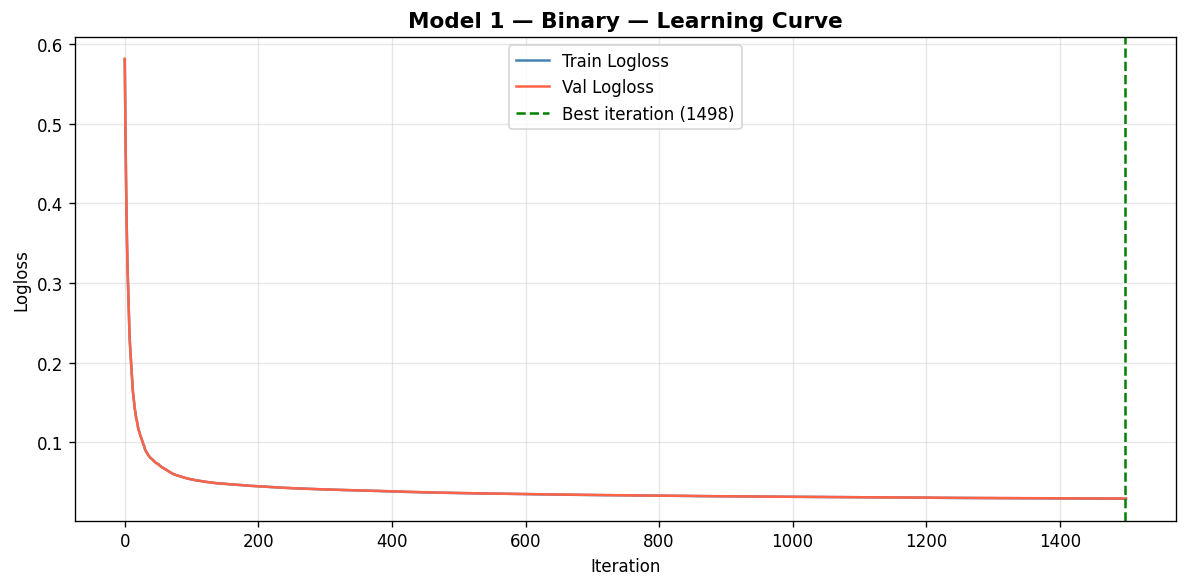

In [12]:
evals      = cat_bin.get_evals_result()
train_loss = evals['learn']['Logloss']
val_loss   = evals['validation']['Logloss']
best_iter  = cat_bin.get_best_iteration()

fig, ax = plt.subplots(figsize=(10, 5), dpi=120)
ax.plot(train_loss, label='Train Logloss', color='steelblue')
ax.plot(val_loss,   label='Val Logloss',   color='tomato')
ax.axvline(best_iter, color='green', linestyle='--',
           label=f'Best iteration ({best_iter})')
ax.set_title('Model 1 — Binary — Learning Curve', fontsize=13, fontweight='bold')
ax.set_xlabel('Iteration')
ax.set_ylabel('Logloss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{plots_dir}/m1_learning_curve.png', dpi=120, bbox_inches='tight')
plt.show()

## Confusion Matrix

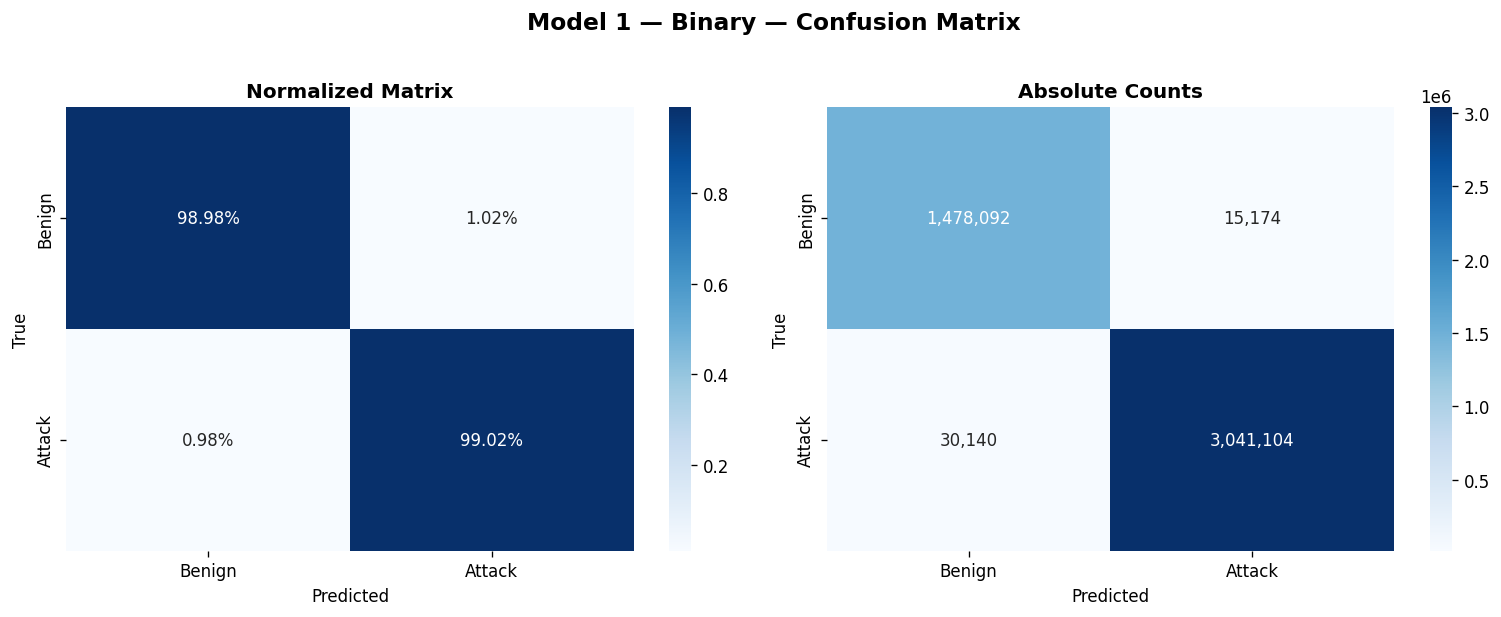

In [13]:
cm_norm = confusion_matrix(y_test_bin, preds_bin, normalize='true')
cm_raw = confusion_matrix(y_test_bin, preds_bin)


fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=120)
labels = ['Benign', 'Attack']

# Left Subplot: Normalized percentages
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Normalized Matrix', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')

# Right Subplot: Raw sample counts
sns.heatmap(cm_raw, annot=True, fmt=',d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title('Absolute Counts', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True')
axes[1].set_xlabel('Predicted')

fig.suptitle('Model 1 — Binary — Confusion Matrix', fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig(f'{plots_dir}/m1_confusion_matrix_side_by_side.png', dpi=120, bbox_inches='tight')
plt.show()


## ROC Curve

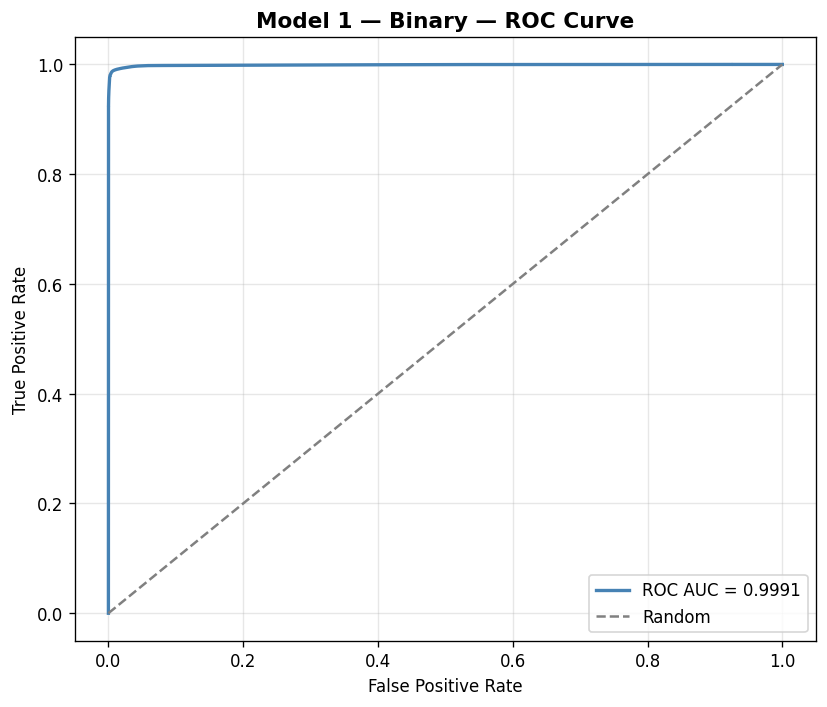

In [14]:
proba_bin   = cat_bin.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test_bin, proba_bin)
roc_auc     = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6), dpi=120)
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC AUC = {roc_auc:.4f}')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random')
ax.set_title('Model 1 — Binary — ROC Curve', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{plots_dir}/m1_roc.png', dpi=120, bbox_inches='tight')
plt.show()

## Precision-Recall Curve

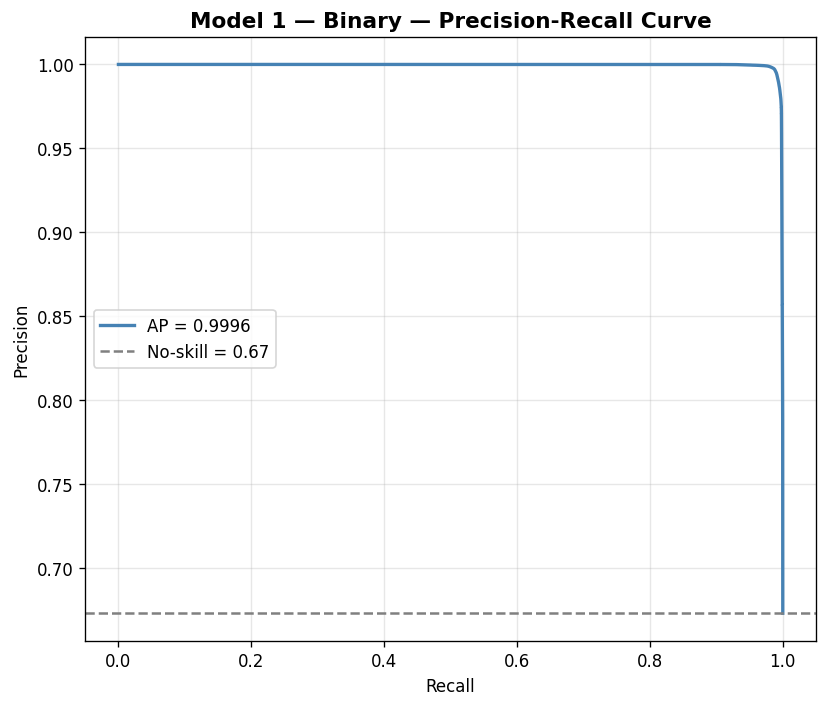

In [15]:
precision, recall, _ = precision_recall_curve(y_test_bin, proba_bin)
ap       = average_precision_score(y_test_bin, proba_bin)
no_skill = y_test_bin.mean()

fig, ax = plt.subplots(figsize=(7, 6), dpi=120)
ax.plot(recall, precision, color='steelblue', lw=2, label=f'AP = {ap:.4f}')
ax.axhline(no_skill, color='gray', linestyle='--', label=f'No-skill = {no_skill:.2f}')
ax.set_title('Model 1 — Binary — Precision-Recall Curve', fontsize=13, fontweight='bold')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{plots_dir}/m1_pr_curve.png', dpi=120, bbox_inches='tight')
plt.show()

## Feature Importance

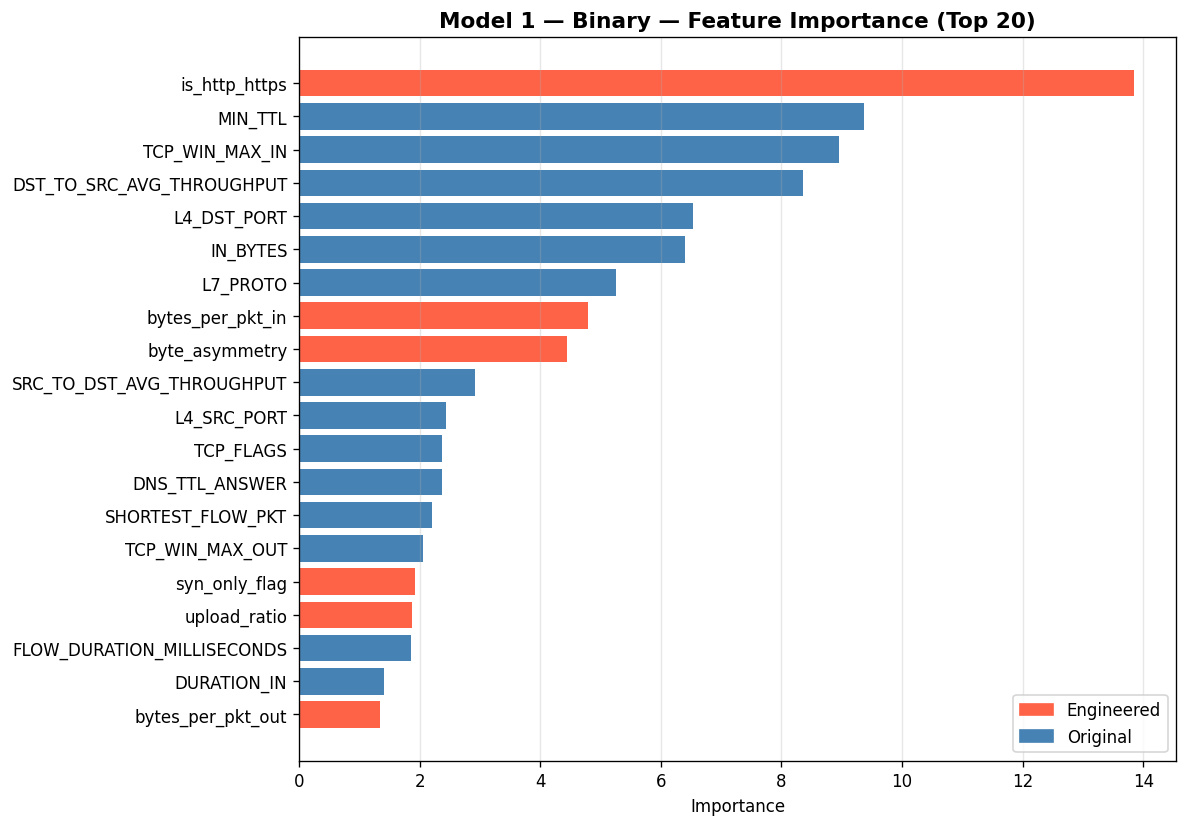

In [16]:
mi_cols    = joblib.load(f'{artefacts_dir}/mi_selected_cols.pkl')
engineered = {
    'bytes_per_pkt_in', 'bytes_per_pkt_out', 'upload_ratio',
    'byte_asymmetry', 'pkt_asymmetry', 'is_http_https',
    'is_ssh_telnet', 'is_dns', 'ttl_range', 'syn_only_flag',
    'pkt_size_range', 'retransmit_ratio', 'retransmit_pkt_ratio'
}

importance = cat_bin.get_feature_importance()
feat_df    = pd.DataFrame({'feature': mi_cols, 'importance': importance})
feat_df    = feat_df.sort_values('importance', ascending=False).head(20)
colors     = ['tomato' if f in engineered else 'steelblue'
               for f in feat_df['feature']]

fig, ax = plt.subplots(figsize=(10, 7), dpi=120)
ax.barh(feat_df['feature'][::-1], feat_df['importance'][::-1], color=colors[::-1])
ax.set_title('Model 1 — Binary — Feature Importance (Top 20)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
patches = [mpatches.Patch(color='tomato',    label='Engineered'),
           mpatches.Patch(color='steelblue', label='Original')]
ax.legend(handles=patches)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f'{plots_dir}/m1_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

## Model 2 
Full Multiclass (21 classes including Benign)


In [17]:
best_params_multi = {
    'iterations'         : 1500,   
    'depth'              : 9,      
    'learning_rate'      : 0.03,  
    'l2_leaf_reg'        : 15.0,   
    'random_strength'    : 2.0,    
    'bagging_temperature': 0.4,    
    'border_count'       : 254,    
}


n_classes_full   = len(np.unique(y_train_multi))
sw_multi         = make_sample_weights(y_train_multi,log_smoothed_multi_dict )
train_pool_multi = Pool(X_train, label=y_train_multi, weight=sw_multi)
val_pool_multi   = Pool(X_val,   label=y_val_multi)

cat_multi = CatBoostClassifier(
    **best_params_multi,
    loss_function='MultiClass',
    eval_metric='MultiClass',
    task_type='GPU',
    random_seed=random_seed,
    verbose=100,
    early_stopping_rounds=50,
    use_best_model=True
)
cat_multi.fit(train_pool_multi, eval_set=val_pool_multi)
cat_multi.save_model(f'{models_dir}/catboost_multiclass.cbm')



0:	learn: 2.5682944	test: 2.5469978	best: 2.5469978 (0)	total: 940ms	remaining: 23m 28s
100:	learn: 0.2433591	test: 0.1977988	best: 0.1977988 (100)	total: 1m 20s	remaining: 18m 36s
200:	learn: 0.1591331	test: 0.1217302	best: 0.1217302 (200)	total: 2m 37s	remaining: 16m 54s
300:	learn: 0.1389423	test: 0.1054576	best: 0.1054576 (300)	total: 3m 49s	remaining: 15m 14s
400:	learn: 0.1298127	test: 0.0982529	best: 0.0982529 (400)	total: 5m	remaining: 13m 43s
500:	learn: 0.1235200	test: 0.0933659	best: 0.0933659 (500)	total: 6m 10s	remaining: 12m 19s
600:	learn: 0.1186902	test: 0.0896503	best: 0.0896503 (600)	total: 7m 21s	remaining: 11m
700:	learn: 0.1152354	test: 0.0869913	best: 0.0869913 (700)	total: 8m 33s	remaining: 9m 44s
800:	learn: 0.1132101	test: 0.0854510	best: 0.0854510 (800)	total: 9m 39s	remaining: 8m 25s
900:	learn: 0.1115188	test: 0.0840968	best: 0.0840968 (900)	total: 10m 43s	remaining: 7m 7s
1000:	learn: 0.1105612	test: 0.0833751	best: 0.0833751 (1000)	total: 11m 44s	remaining

## Test model_2 performance on the test set

In [18]:
preds_multi = evaluate(cat_multi, X_test, y_test_multi,
                        label='Model 2 — Full Multiclass — Test Set',
                        class_names=le.classes_)


Model 2 — Full Multiclass — Test Set
Accuracy         : 0.9770
Macro-F1         : 0.7932
Weighted-F1      : 0.9762
                precision    recall  f1-score   support

      Analysis       0.14      0.63      0.22        75
      Backdoor       0.97      0.94      0.96      1165
        Benign       0.98      0.99      0.98   1493266
           Bot       1.00      1.00      1.00      3920
   Brute Force       1.00      0.98      0.99      8165
          DDoS       0.99      0.99      0.99   1310954
           DoS       0.98      0.99      0.99   1088123
      Exploits       0.74      0.88      0.81      1984
       Fuzzers       0.72      0.93      0.81      1384
       Generic       0.75      0.80      0.77       645
 Infilteration       0.91      0.09      0.16      7646
Reconnaissance       0.89      0.82      0.85    166365
     Shellcode       0.74      0.86      0.79        76
         Theft       0.44      0.92      0.60       141
         Worms       0.92      0.52      0.

## Learning Curve

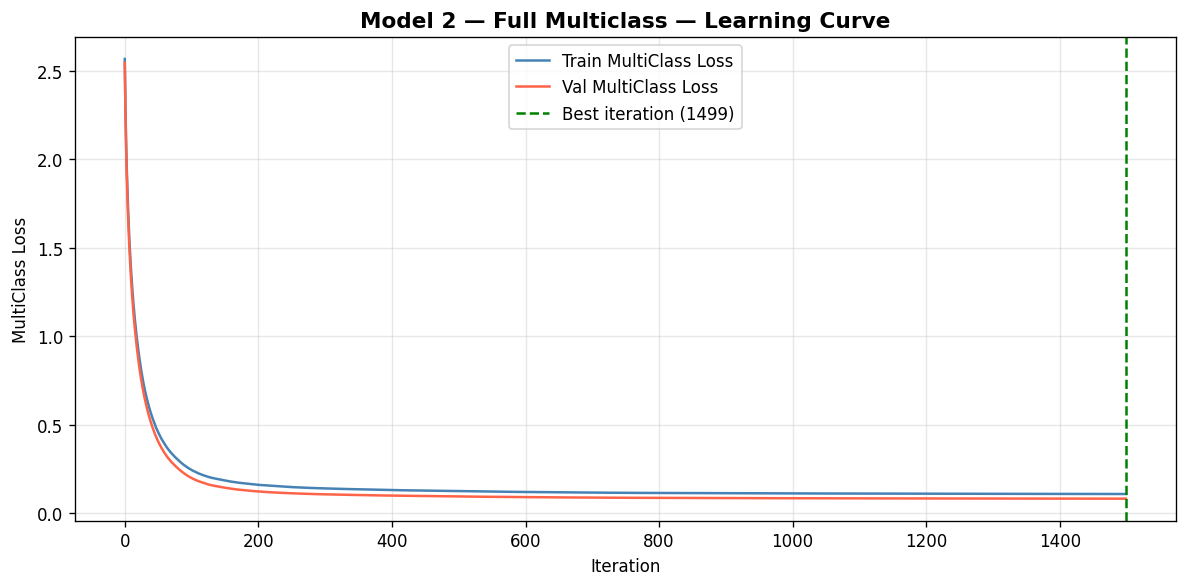

In [19]:
evals      = cat_multi.get_evals_result()
train_loss = evals['learn']['MultiClass']
val_loss   = evals['validation']['MultiClass']
best_iter  = cat_multi.get_best_iteration()

fig, ax = plt.subplots(figsize=(10, 5), dpi=120)
ax.plot(train_loss, label='Train MultiClass Loss', color='steelblue')
ax.plot(val_loss,   label='Val MultiClass Loss',   color='tomato')
ax.axvline(best_iter, color='green', linestyle='--',
           label=f'Best iteration ({best_iter})')
ax.set_title('Model 2 — Full Multiclass — Learning Curve', fontsize=13, fontweight='bold')
ax.set_xlabel('Iteration')
ax.set_ylabel('MultiClass Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{plots_dir}/m2_learning_curve.png', dpi=120, bbox_inches='tight')
plt.show()

## Confusion Matrix

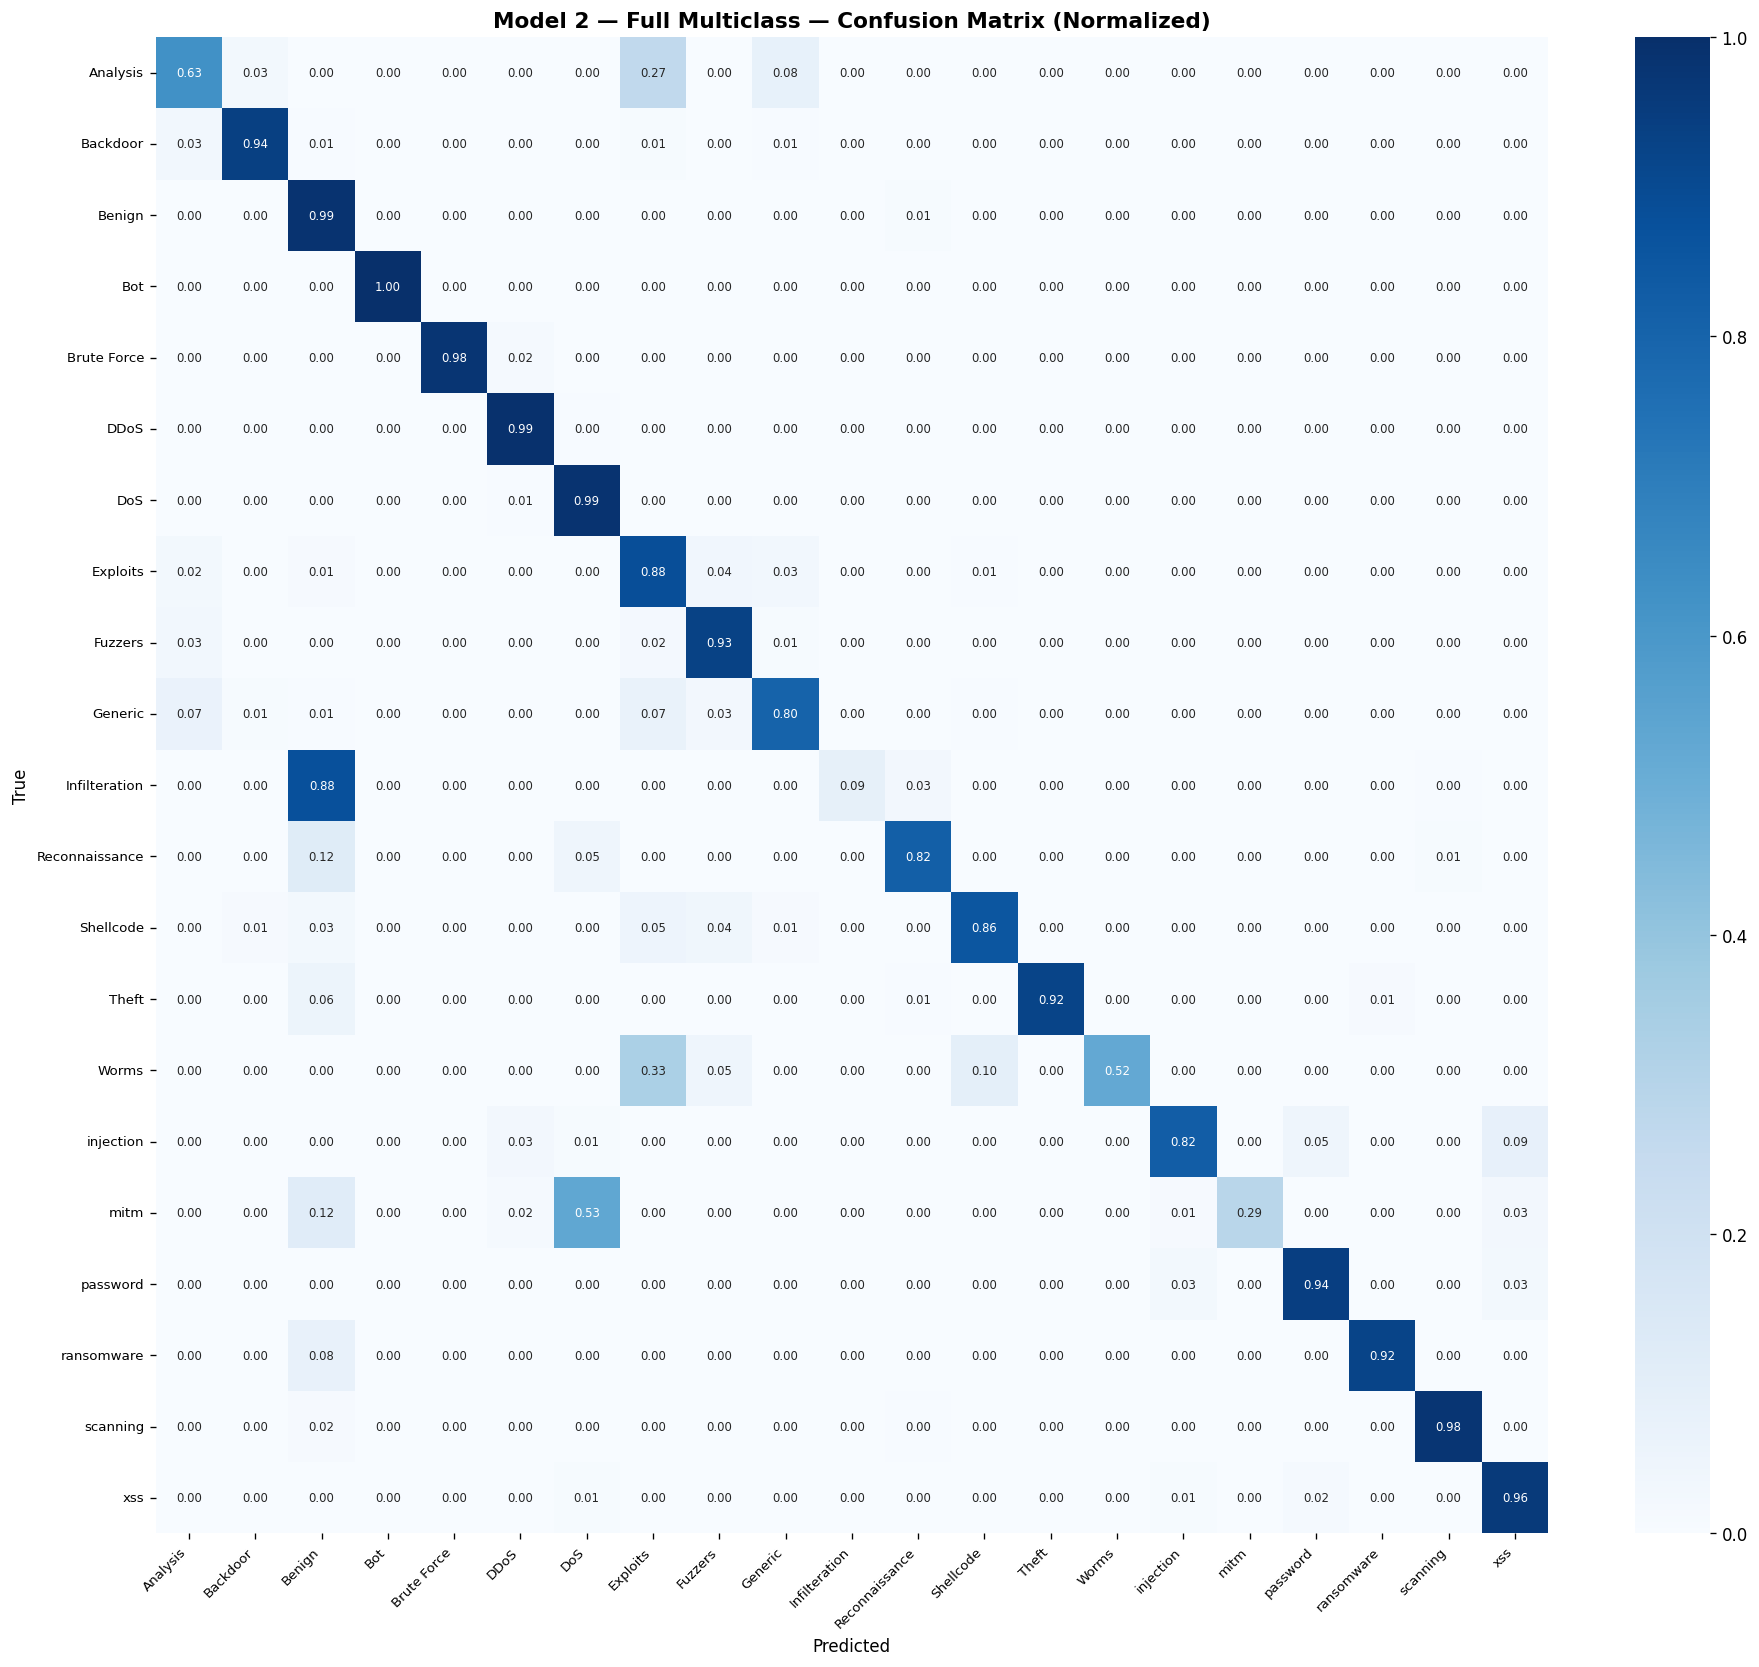

In [20]:
cm = confusion_matrix(y_test_multi, preds_multi, normalize='true')
fig, ax = plt.subplots(figsize=(16, 14), dpi=120)
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_, ax=ax,
            annot_kws={'size': 7})
ax.set_title('Model 2 — Full Multiclass — Confusion Matrix (Normalized)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('True')
ax.set_xlabel('Predicted')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(f'{plots_dir}/m2_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

## Per_class F1 bar chart

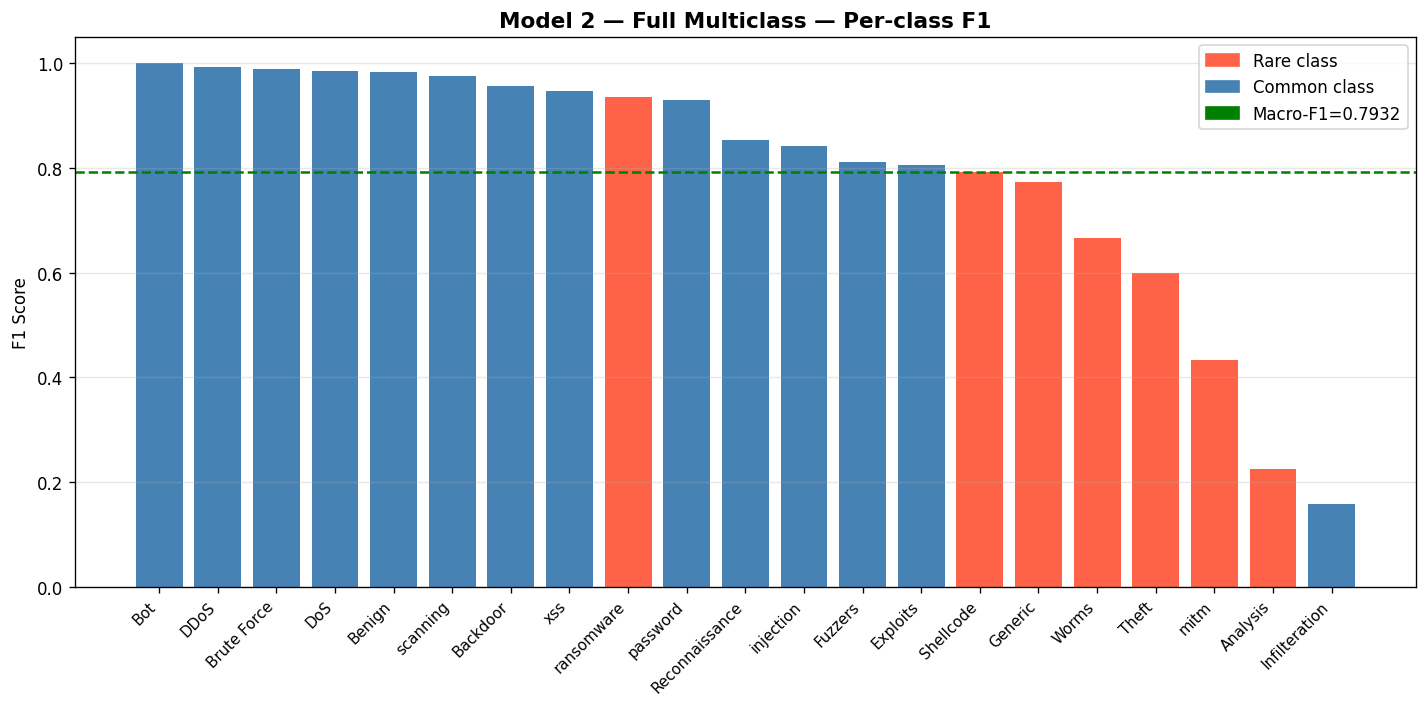

In [21]:
report   = classification_report(y_test_multi, preds_multi,
                                  target_names=le.classes_,
                                  output_dict=True, zero_division=0)
f1_vals  = {cls: report[cls]['f1-score'] for cls in le.classes_}
f1_df    = pd.DataFrame(list(f1_vals.items()), columns=['class', 'f1'])
f1_df    = f1_df.sort_values('f1', ascending=False)
macro_f1 = report['macro avg']['f1-score']

rare   = {'Worms','Shellcode','Analysis','Theft','ransomware','mitm','Generic'}
colors = ['tomato' if c in rare else 'steelblue' for c in f1_df['class']]

fig, ax = plt.subplots(figsize=(12, 6), dpi=120)
ax.bar(f1_df['class'], f1_df['f1'], color=colors)
ax.axhline(macro_f1, color='green', linestyle='--',
           label=f'Macro-F1 = {macro_f1:.4f}')
ax.set_title('Model 2 — Full Multiclass — Per-class F1',
             fontsize=13, fontweight='bold')
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.05)
plt.xticks(rotation=45, ha='right', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
patches = [mpatches.Patch(color='tomato',    label='Rare class'),
           mpatches.Patch(color='steelblue', label='Common class'),
           mpatches.Patch(color='green',     label=f'Macro-F1={macro_f1:.4f}')]
ax.legend(handles=patches)
plt.tight_layout()
plt.savefig(f'{plots_dir}/m2_per_class_f1.png', dpi=120, bbox_inches='tight')
plt.show()

## Per_class Precision_Recall heatmap

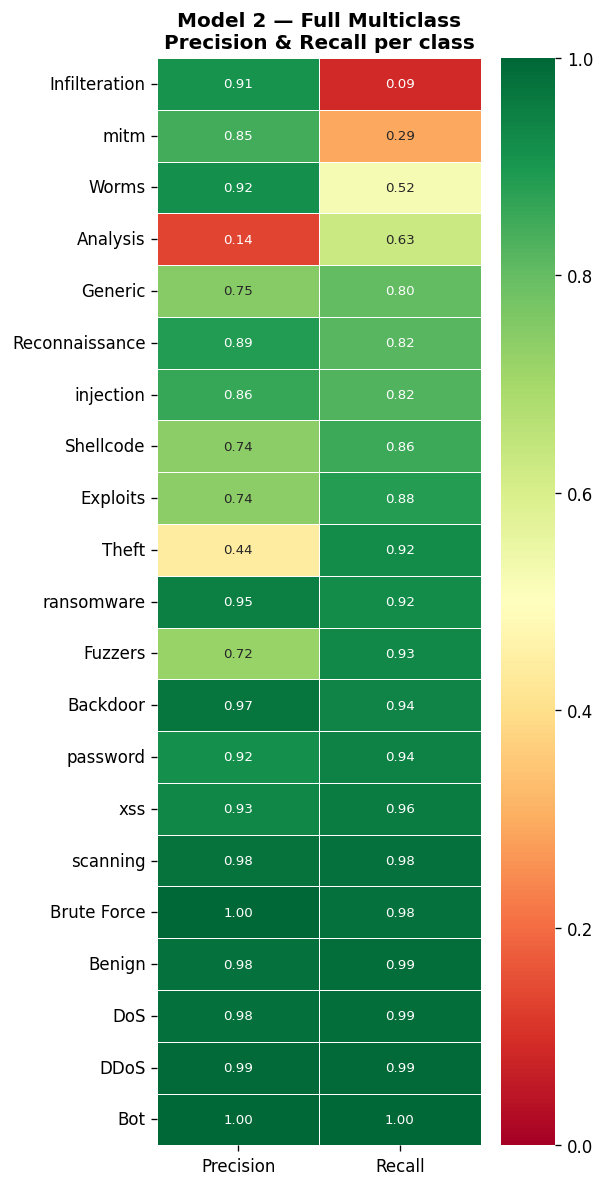

In [22]:
prec_vals = {cls: report[cls]['precision'] for cls in le.classes_}
rec_vals  = {cls: report[cls]['recall']    for cls in le.classes_}
pr_df     = pd.DataFrame({'Precision': prec_vals, 'Recall': rec_vals})
pr_df     = pr_df.sort_values('Recall', ascending=True)

fig, ax = plt.subplots(figsize=(5, 10), dpi=120)
sns.heatmap(pr_df, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0, vmax=1, ax=ax, linewidths=0.5,
            annot_kws={'size': 8})
ax.set_title('Model 2 — Full Multiclass\nPrecision & Recall per class',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{plots_dir}/m2_precision_recall_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

## Feature Importance

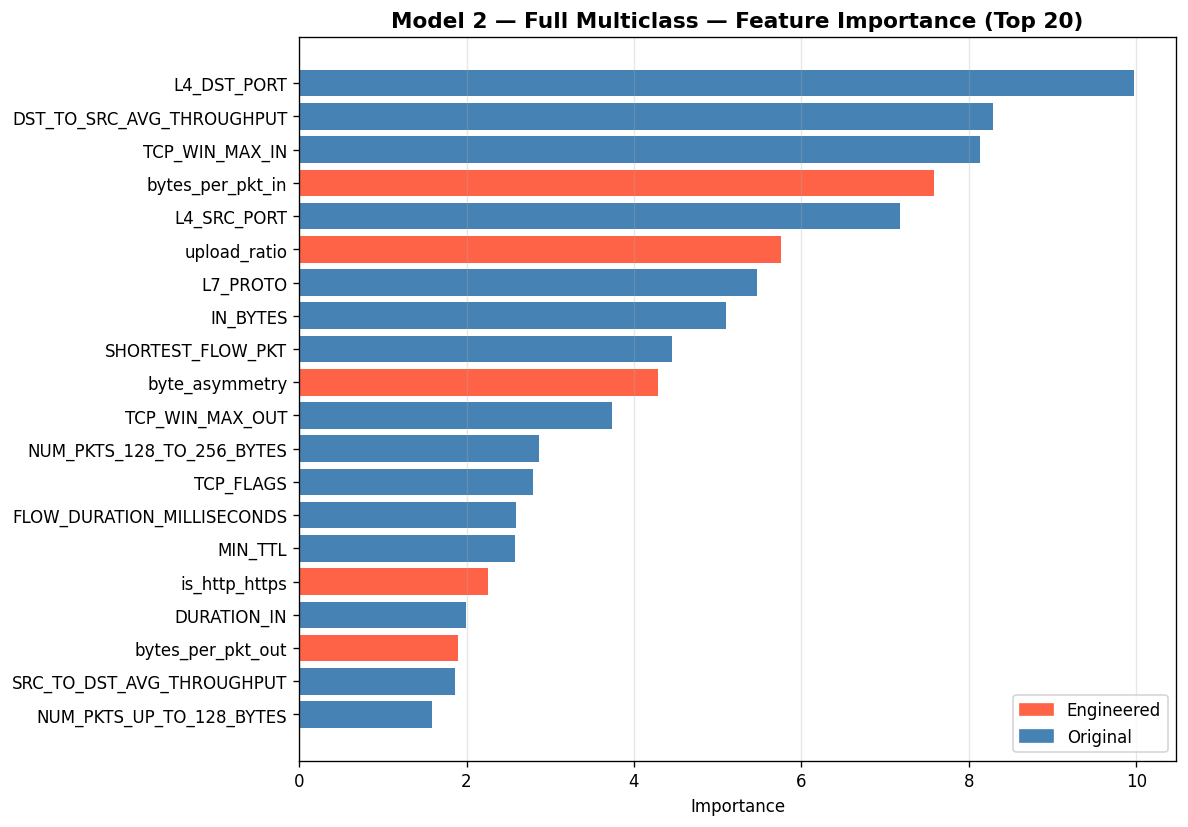

In [23]:
importance = cat_multi.get_feature_importance()
feat_df    = pd.DataFrame({'feature': mi_cols, 'importance': importance})
feat_df    = feat_df.sort_values('importance', ascending=False).head(20)
colors     = ['tomato' if f in engineered else 'steelblue'
               for f in feat_df['feature']]

fig, ax = plt.subplots(figsize=(10, 7), dpi=120)
ax.barh(feat_df['feature'][::-1], feat_df['importance'][::-1], color=colors[::-1])
ax.set_title('Model 2 — Full Multiclass — Feature Importance (Top 20)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
patches = [mpatches.Patch(color='tomato',    label='Engineered'),
           mpatches.Patch(color='steelblue', label='Original')]
ax.legend(handles=patches)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f'{plots_dir}/m2_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

## Model 3
Attack Only Multiclass (20 classes, no Benign)


In [24]:
best_params_att = {
    'iterations'         : 1200,   
    'depth'              : 7,      # Kept at 7: Prevents deep over-partitioning of heavy attack classes
    'learning_rate'      : 0.04,   
    'l2_leaf_reg'        : 25.0,   # Massive L2 restriction: stops rare classes from pulling leaves to extremes
    'random_strength'    : 1.0,    # Drop down: forces the model to focus on stable structural features
    'bagging_temperature': 0.1,    # High bagging focus: heavily penalizes speculative multi-class boundaries
    'border_count'       : 254,    
}



n_classes_att  = len(np.unique(y_train_att_multi))
sw_att         = make_sample_weights(y_train_att_multi, log_smoothed_att_dict)
train_pool_att = Pool(X_train_att, label=y_train_att_multi, weight=sw_att)
val_pool_att   = Pool(X_val_att,   label=y_val_att_multi)

cat_att = CatBoostClassifier(
    **best_params_att,
    loss_function='MultiClass',
    eval_metric='MultiClass',
    task_type='GPU',
    random_seed=random_seed,
    verbose=100,
    early_stopping_rounds=50,
    use_best_model=True
)
cat_att.fit(train_pool_att, eval_set=val_pool_att)
cat_att.save_model(f'{models_dir}/catboost_att_multiclass.cbm')



0:	learn: 2.3935358	test: 2.3664652	best: 2.3664652 (0)	total: 476ms	remaining: 9m 31s
100:	learn: 0.1722275	test: 0.1425735	best: 0.1425735 (100)	total: 38.4s	remaining: 6m 57s
200:	learn: 0.1249819	test: 0.1030330	best: 0.1030330 (200)	total: 1m 12s	remaining: 5m 58s
300:	learn: 0.1088940	test: 0.0903091	best: 0.0903091 (300)	total: 1m 46s	remaining: 5m 17s
400:	learn: 0.1006579	test: 0.0836588	best: 0.0836588 (400)	total: 2m 20s	remaining: 4m 40s
500:	learn: 0.0948378	test: 0.0789573	best: 0.0789573 (500)	total: 2m 55s	remaining: 4m 4s
600:	learn: 0.0910670	test: 0.0760276	best: 0.0760276 (600)	total: 3m 29s	remaining: 3m 29s
700:	learn: 0.0883897	test: 0.0739649	best: 0.0739649 (700)	total: 4m 3s	remaining: 2m 53s
800:	learn: 0.0860519	test: 0.0720970	best: 0.0720970 (800)	total: 4m 37s	remaining: 2m 18s
900:	learn: 0.0844274	test: 0.0708724	best: 0.0708724 (900)	total: 5m 11s	remaining: 1m 43s
1000:	learn: 0.0826520	test: 0.0694998	best: 0.0694998 (1000)	total: 5m 45s	remaining: 1

## Test model_3 performance on the test set

In [25]:
attack_classes = [c for c in le.classes_ if c != 'Benign']
preds_att = evaluate(cat_att, X_test_att, y_test_att_multi,
                      label='Model_3_Attack_Only_Test_Set',
                      class_names=attack_classes)


Model_3_Attack_Only_Test_Set
Accuracy         : 0.9816
Macro-F1         : 0.8451
Weighted-F1      : 0.9815
                precision    recall  f1-score   support

      Analysis       0.16      0.64      0.25        75
      Backdoor       0.97      0.94      0.95      1165
           Bot       1.00      1.00      1.00      3920
   Brute Force       1.00      0.98      0.99      8165
          DDoS       0.99      0.99      0.99   1310954
           DoS       0.98      0.99      0.99   1088123
      Exploits       0.81      0.90      0.86      1984
       Fuzzers       0.90      0.93      0.92      1384
       Generic       0.79      0.81      0.80       645
 Infilteration       0.89      0.86      0.88      7646
Reconnaissance       0.97      0.93      0.95    166365
     Shellcode       0.76      0.89      0.82        76
         Theft       0.46      0.96      0.62       141
         Worms       0.79      0.71      0.75        21
     injection       0.86      0.83      0.85     4

## Learning Curve

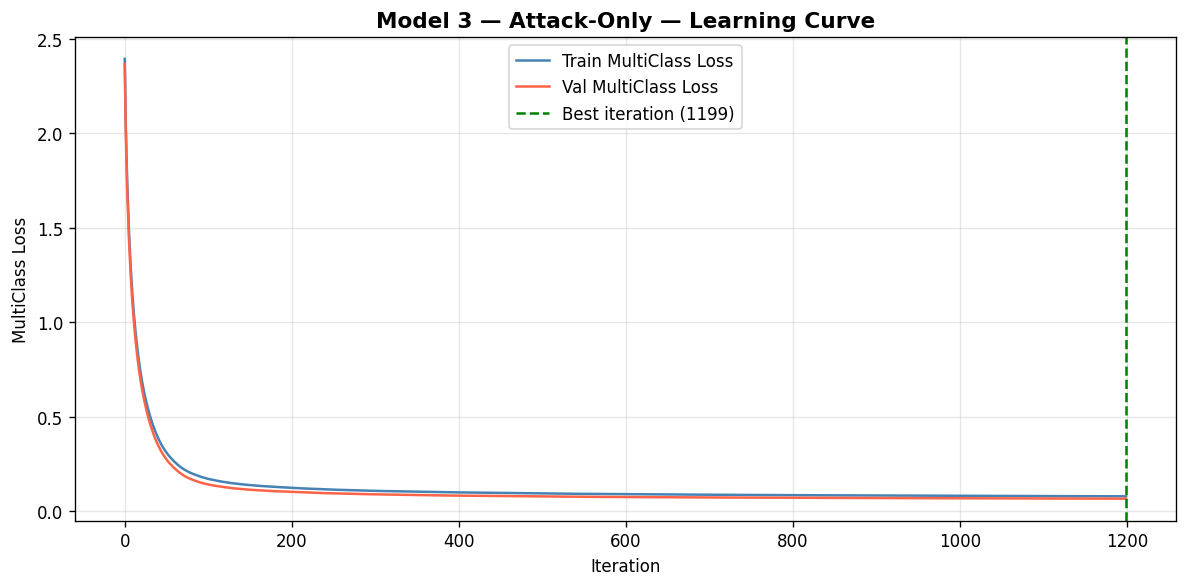

In [26]:
evals      = cat_att.get_evals_result()
train_loss = evals['learn']['MultiClass']
val_loss   = evals['validation']['MultiClass']
best_iter  = cat_att.get_best_iteration()

fig, ax = plt.subplots(figsize=(10, 5), dpi=120)
ax.plot(train_loss, label='Train MultiClass Loss', color='steelblue')
ax.plot(val_loss,   label='Val MultiClass Loss',   color='tomato')
ax.axvline(best_iter, color='green', linestyle='--',
           label=f'Best iteration ({best_iter})')
ax.set_title('Model 3 — Attack-Only — Learning Curve', fontsize=13, fontweight='bold')
ax.set_xlabel('Iteration')
ax.set_ylabel('MultiClass Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{plots_dir}/m3_learning_curve.png', dpi=120, bbox_inches='tight')
plt.show()

## Confusion Matrix

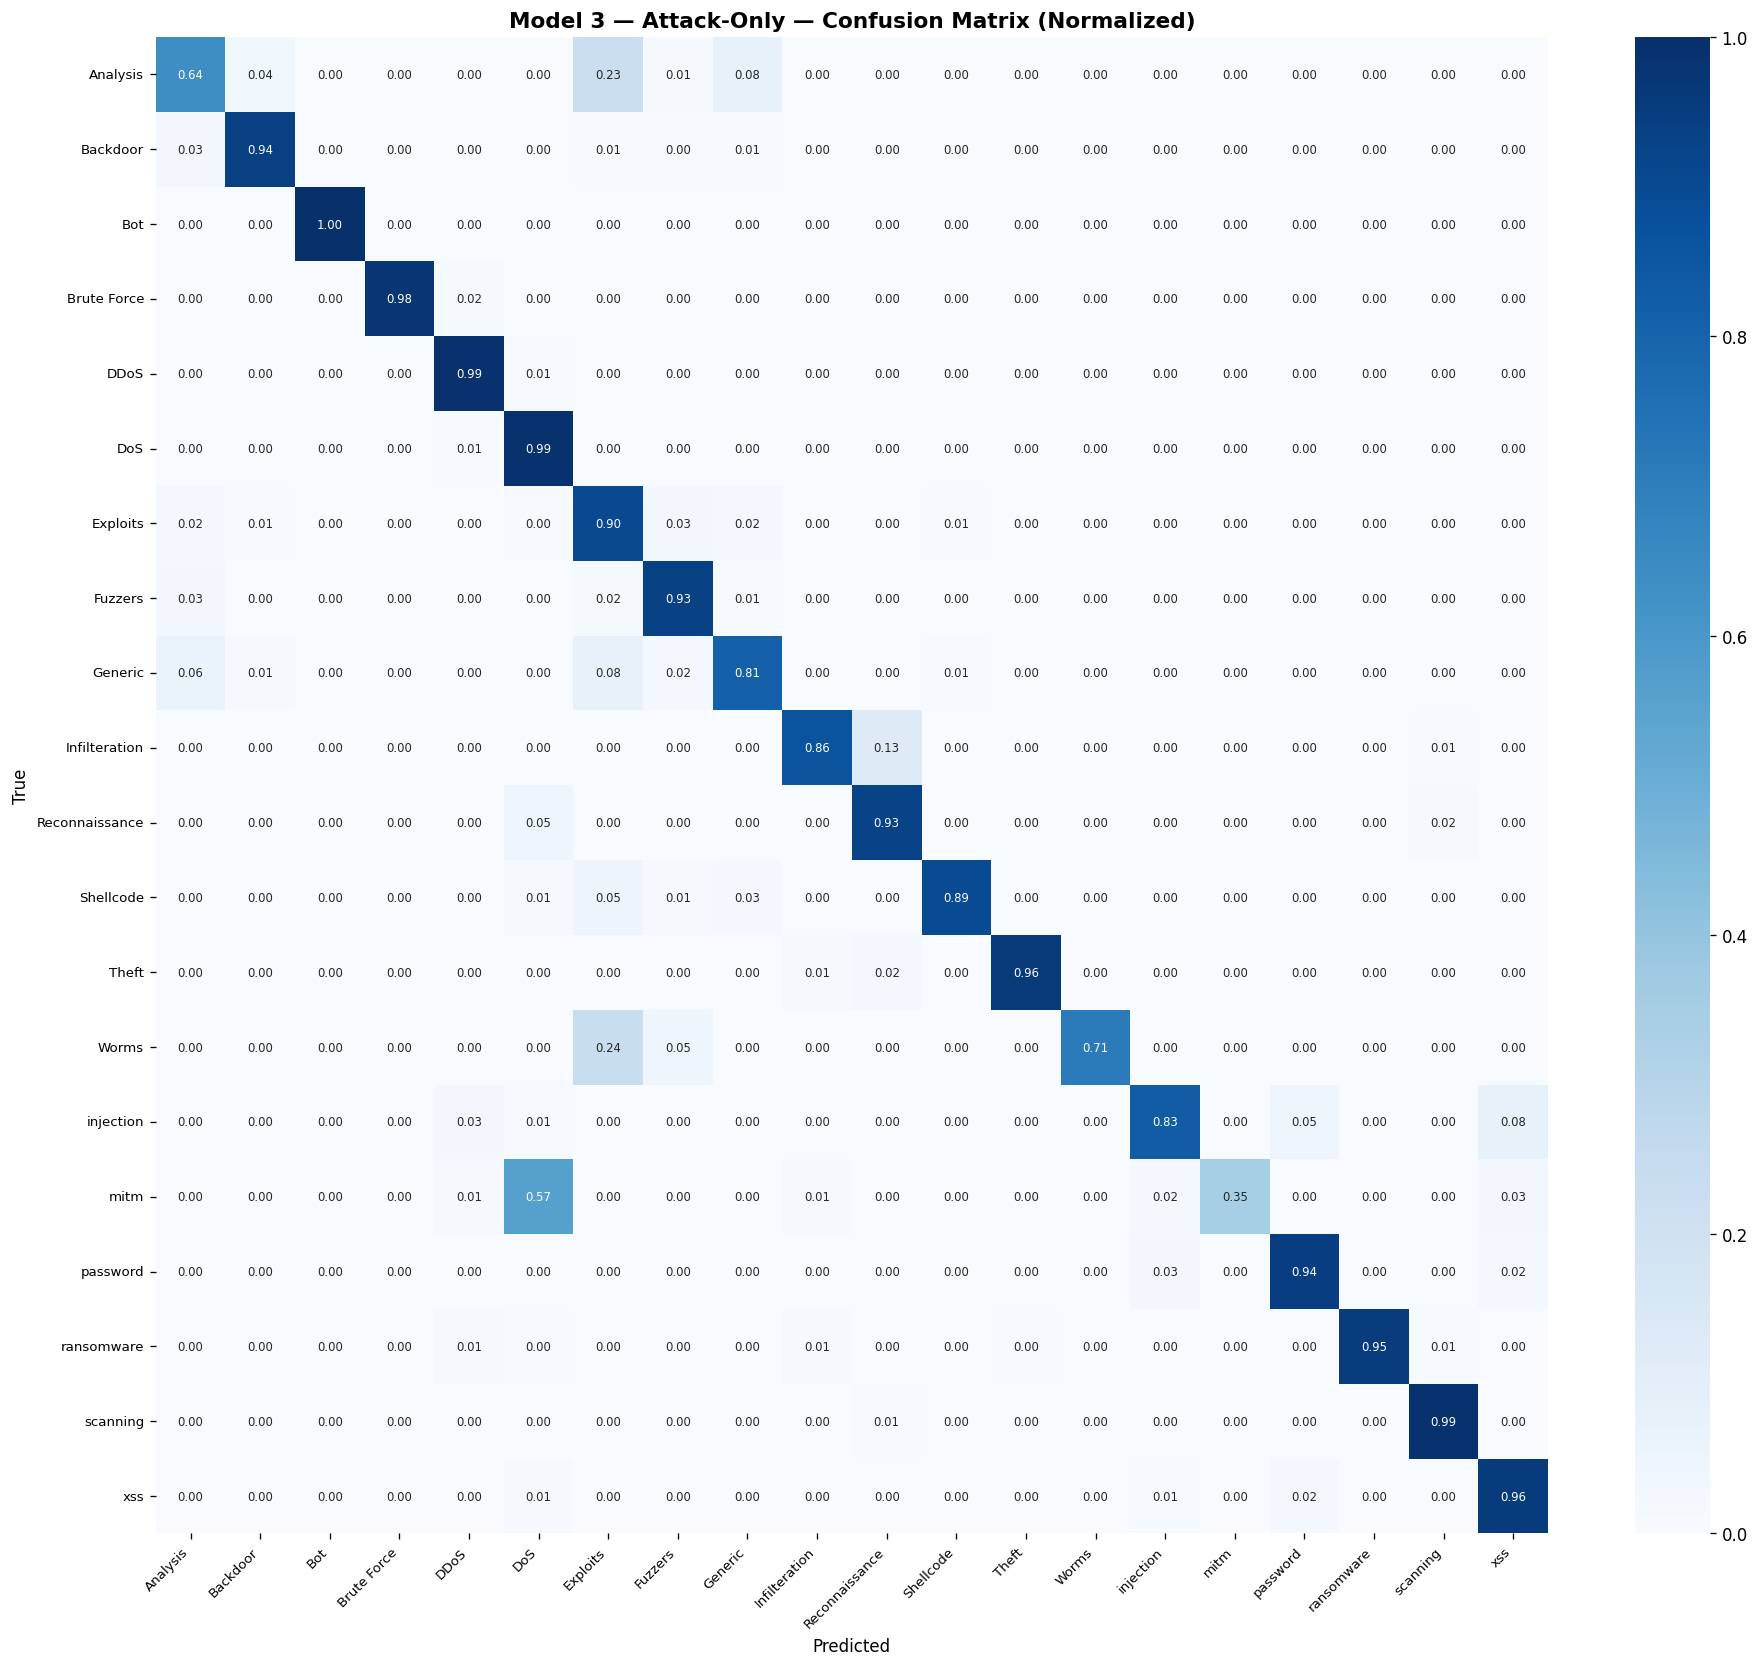

In [27]:
attack_classes = [c for c in le.classes_ if c != 'Benign']
cm = confusion_matrix(y_test_att_multi, preds_att, normalize='true')
fig, ax = plt.subplots(figsize=(16, 14), dpi=120)
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=attack_classes,
            yticklabels=attack_classes, ax=ax,
            annot_kws={'size': 7})
ax.set_title('Model 3 — Attack-Only — Confusion Matrix (Normalized)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('True')
ax.set_xlabel('Predicted')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(f'{plots_dir}/m3_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

## Per_class F1 bar chart

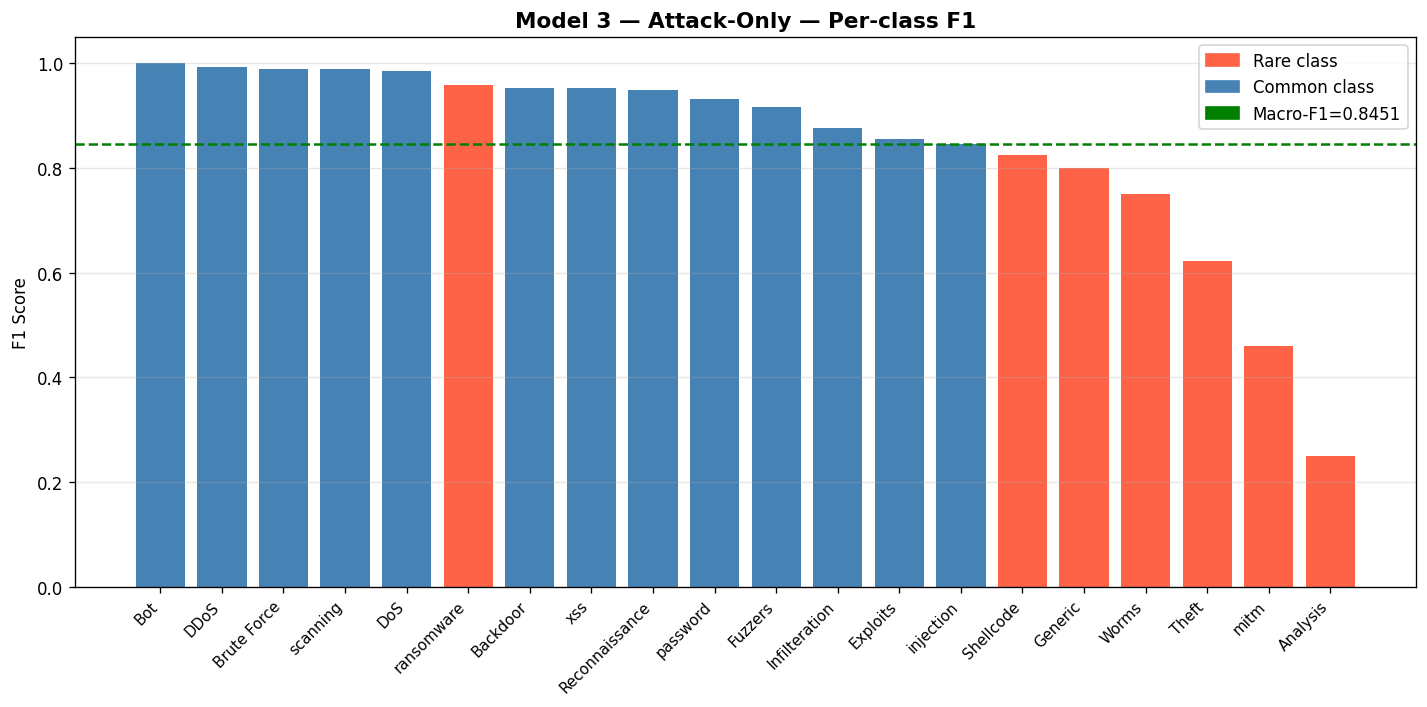

In [28]:
report_att = classification_report(y_test_att_multi, preds_att,
                                    target_names=attack_classes,
                                    output_dict=True, zero_division=0)
f1_vals_att  = {cls: report_att[cls]['f1-score'] for cls in attack_classes}
f1_df_att    = pd.DataFrame(list(f1_vals_att.items()), columns=['class', 'f1'])
f1_df_att    = f1_df_att.sort_values('f1', ascending=False)
macro_f1_att = report_att['macro avg']['f1-score']

colors = ['tomato' if c in rare else 'steelblue' for c in f1_df_att['class']]

fig, ax = plt.subplots(figsize=(12, 6), dpi=120)
ax.bar(f1_df_att['class'], f1_df_att['f1'], color=colors)
ax.axhline(macro_f1_att, color='green', linestyle='--',
           label=f'Macro-F1 = {macro_f1_att:.4f}')
ax.set_title('Model 3 — Attack-Only — Per-class F1',
             fontsize=13, fontweight='bold')
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.05)
plt.xticks(rotation=45, ha='right', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
patches = [mpatches.Patch(color='tomato',    label='Rare class'),
           mpatches.Patch(color='steelblue', label='Common class'),
           mpatches.Patch(color='green',     label=f'Macro-F1={macro_f1_att:.4f}')]
ax.legend(handles=patches)
plt.tight_layout()
plt.savefig(f'{plots_dir}/m3_per_class_f1.png', dpi=120, bbox_inches='tight')
plt.show()

## Per_class Precision_Recall heatmap

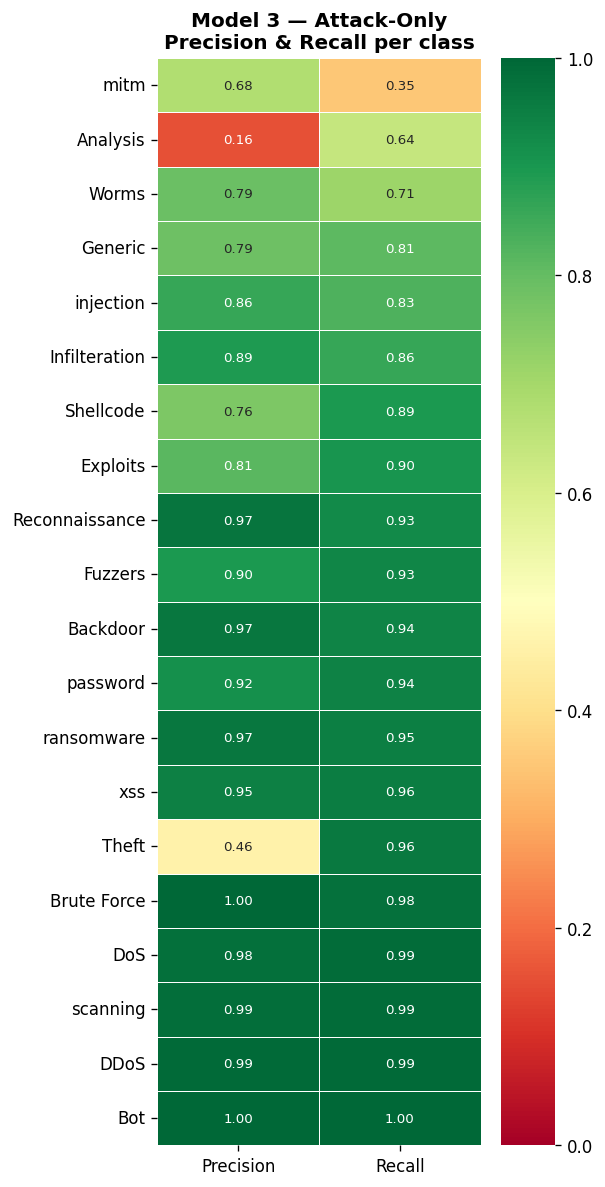

In [29]:
prec_vals_att = {cls: report_att[cls]['precision'] for cls in attack_classes}
rec_vals_att  = {cls: report_att[cls]['recall']    for cls in attack_classes}
pr_df_att     = pd.DataFrame({'Precision': prec_vals_att, 'Recall': rec_vals_att})
pr_df_att     = pr_df_att.sort_values('Recall', ascending=True)

fig, ax = plt.subplots(figsize=(5, 10), dpi=120)
sns.heatmap(pr_df_att, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0, vmax=1, ax=ax, linewidths=0.5,
            annot_kws={'size': 8})
ax.set_title('Model 3 — Attack-Only\nPrecision & Recall per class',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{plots_dir}/m3_precision_recall_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

## Feature Importance

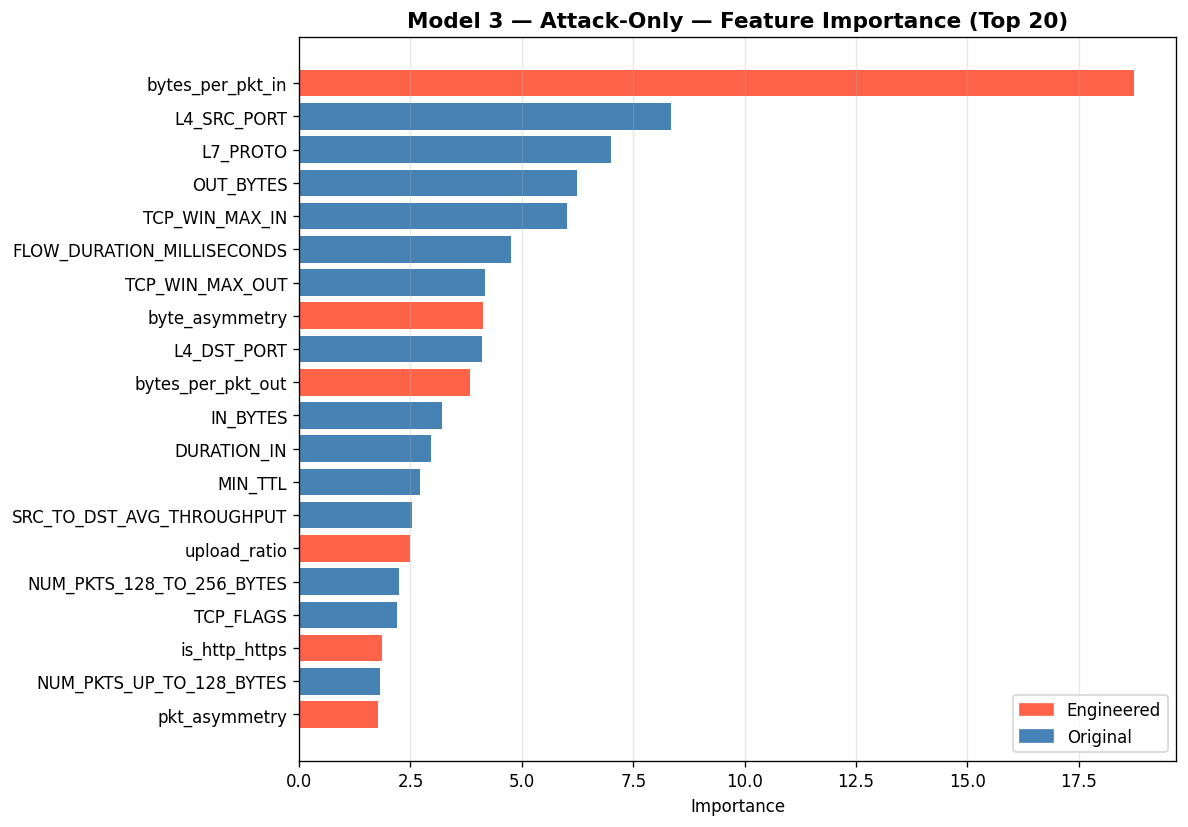

In [30]:
importance = cat_att.get_feature_importance()
feat_df    = pd.DataFrame({'feature': mi_cols, 'importance': importance})
feat_df    = feat_df.sort_values('importance', ascending=False).head(20)
colors     = ['tomato' if f in engineered else 'steelblue'
               for f in feat_df['feature']]

fig, ax = plt.subplots(figsize=(10, 7), dpi=120)
ax.barh(feat_df['feature'][::-1], feat_df['importance'][::-1], color=colors[::-1])
ax.set_title('Model 3 — Attack-Only — Feature Importance (Top 20)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
patches = [mpatches.Patch(color='tomato',    label='Engineered'),
           mpatches.Patch(color='steelblue', label='Original')]
ax.legend(handles=patches)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f'{plots_dir}/m3_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

## Papers comparison done on the same dataset NF-UQ-NID

In [38]:
papers = [
    "Sarhan\n2022",
    "Wijethilaka\n2025",
    "Mouatassim\n2024",
    "Bouzaachane\n2025",
    "Gu\n2024",
    "Krupski\n2024",
    "Komisarek\n2021",
    "Gouda\n2024",
    "Adeniyi\n2024",
    "My Models"
]

In [39]:
# Binary
binary_scores = [
    0.9800,      # Sarhan ET Binary
    0.9480,      # Wijethilaka RF
    0.999939,    # Mouatassim XGB Binary
    1.0000,      # Bouzaachane RF Binary
    np.nan,      # Gu
    0.9530,      # Krupski DT 8feat
    0.9800,      # Komisarek RF
    0.9910,      # Gouda RF
    0.9890,      # Adeniyi AE-MLP
    0.9901       # My Binary
]

# Full multiclass
multi_scores = [
    0.9700,      # Sarhan ET Multi
    0.8750,      # Wijethilaka LSTM
    0.9928,      # Mouatassim XGB Multi
    0.9900,      # Bouzaachane DBN Multi
    0.8900,      # Gu GNN
    0.9720,      # Krupski DT 30feat
    np.nan,
    np.nan,
    np.nan,
    0.9762       # My Full Multi
]

# Attack-only multiclass
attack_only_scores = [
    np.nan,
    np.nan,
    np.nan,
    np.nan,
    np.nan,
    np.nan,
    np.nan,
    np.nan,
    np.nan,
    0.9815       # My Attack-only
]

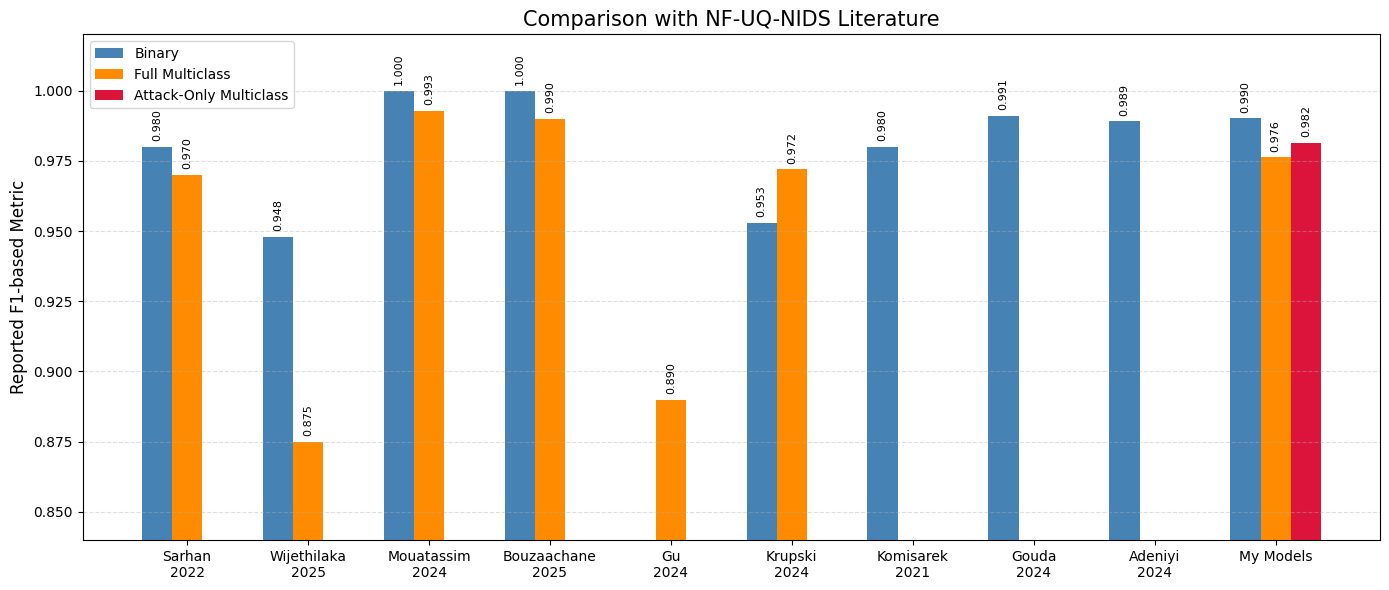

In [40]:
x = np.arange(len(papers))
width = 0.25
plt.figure(figsize=(14, 6))
bars1 = plt.bar( x - width,binary_scores,width,label='Binary',color='steelblue')
bars2 = plt.bar(x,multi_scores,width, label='Full Multiclass', color='darkorange')
bars3 = plt.bar(x + width,attack_only_scores, width,label='Attack-Only Multiclass', color='crimson')
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()

        if not np.isnan(height):
            plt.text(bar.get_x() + bar.get_width()/2,  height + 0.002,f"{height:.3f}", ha='center',va='bottom', fontsize=8, rotation=90  )


plt.xticks(x, papers, fontsize=10)
plt.ylabel("Reported F1-based Metric", fontsize=12)
plt.title("Comparison with NF-UQ-NIDS Literature",fontsize=15)
plt.ylim(0.84, 1.02)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.savefig(f'{plots_dir}/papers_comparison', dpi=120, bbox_inches='tight')
plt.show()

## Saving ther Artefacts and the Models

In [41]:
import os
import shutil
from IPython.display import FileLink, display

models_dir = '/kaggle/working/models_catboost'
models_zip = 'catboost_models.zip'

if os.path.exists(models_dir):
    shutil.make_archive('catboost_models', 'zip', models_dir)
    print(" CatBoost :")
    display(FileLink(models_zip))
else:
    print(f" Not found: {models_dir}")


 CatBoost :


/kaggle/working/catboost_models.zip

In [42]:
plots_dir = '/kaggle/working/plots_catboost'
plots_zip = 'catboost_plots.zip'

if os.path.exists(plots_dir):
    shutil.make_archive('catboost_plots', 'zip', plots_dir)
    print("CatBoost Plots:")
    display(FileLink(plots_zip))
else:
    print(f" Not found: {plots_dir}")


CatBoost Plots:


/kaggle/working/catboost_plots.zip